# Clasificación Básica: Predecir una imagen de moda

Esta Guia entrena un modelo de red neuronal para clasificar imagenes de ropa como, tennis y camisetas.

Esta Guia usa [tf.keras](https://www.tensorflow.org/guide/keras), un API de alto nivel para construir y entrenar modelos en Tensorflow.

## Importar el set de datos de moda de MNIST

Esta guia usa el set de datos de [Fashion MNIST](https://github.com/zalandoresearch/fashion-mnist)
que contiene mas de 70,000 imagenes en 10 categorias. Las imagenes muestran articulos individuales de ropa a una resolucion baja (28 por 28 pixeles) como se ve aca:

<table>
  <tr><td>
    <img src="https://tensorflow.org/images/fashion-mnist-sprite.png"
         alt="Fashion MNIST sprite"  width="600">
  </td></tr>
  <tr><td align="center">
    <b>Figure 1.</b> <a href="https://github.com/zalandoresearch/fashion-mnist">Fashion-MNIST samples</a> (by Zalando, MIT License).<br/>&nbsp;
  </td></tr>
</table>

Para importar y cargar el set de datos de MNIST directamente de TensorFlow:

In [55]:
from tensorflow import keras
from tensorflow.keras import layers
import pandas as pd
import numpy as np
from tensorflow.keras.datasets import fashion_mnist
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report


In [20]:
# keras.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

train_images, val_images, train_labels, val_labels = train_test_split(train_images, train_labels, test_size=0.2,random_state=10)


La *class* de ropa que la imagen representa.

<table>
  <tr>
    <th>Label</th>
    <th>Class</th>
  </tr>
  <tr>
    <td>0</td>
    <td>T-shirt/top</td>
  </tr>
  <tr>
    <td>1</td>
    <td>Trouser</td>
  </tr>
    <tr>
    <td>2</td>
    <td>Pullover</td>
  </tr>
    <tr>
    <td>3</td>
    <td>Dress</td>
  </tr>
    <tr>
    <td>4</td>
    <td>Coat</td>
  </tr>
    <tr>
    <td>5</td>
    <td>Sandal</td>
  </tr>
    <tr>
    <td>6</td>
    <td>Shirt</td>
  </tr>
    <tr>
    <td>7</td>
    <td>Sneaker</td>
  </tr>
    <tr>
    <td>8</td>
    <td>Bag</td>
  </tr>
    <tr>
    <td>9</td>
    <td>Ankle boot</td>
  </tr>
</table>

Cada imagen es mapeada a una unica etiqueta. Ya que los *Class names* no estan incluidos en el dataset.

In [21]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

## Explore el set de datos

* ¿Cuántas imágenes hay en train?
* ¿Y en test?
* ¿De cuántos pixels se compone cada imagen?
* ¿Cuáles son los valores de los labels?

In [22]:
print(train_images.shape)
print(test_images.shape)
print(train_labels.shape)
print(test_labels.shape)

(48000, 28, 28)
(10000, 28, 28)
(48000,)
(10000,)


## Pre-procese el set de datos

Inspecciona y representa la primera imagen del dataset de train. Para ello, utiliza la función `imshow` de matplotlib.

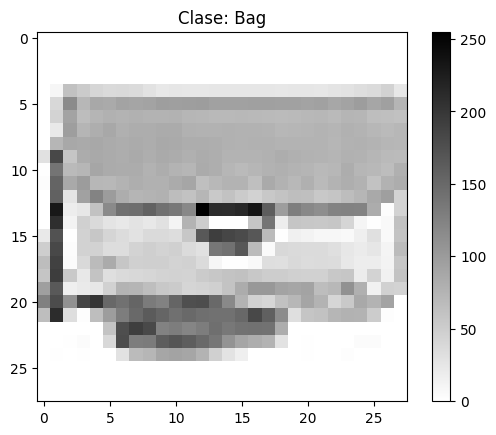

In [23]:
plt.figure()
plt.imshow(train_images[0], cmap=plt.cm.binary)  # cmap='gray' para escala de grises
plt.title(f"Clase: {class_names[train_labels[0]]}")
plt.colorbar()
plt.show()

Escala los conjuntos de train y test para que vayan del 0 al 1. No hace falta usar ninguna librería. Con realizar una división en cada conjunto será suficiente.

In [24]:
train_images = train_images / 255.0
test_images = test_images / 255.0


Para verificar que el set de datos está en el formato adecuado y que están listos para construir y entrenar la red, vamos a desplegar las primeras 25 imágenes del *training set* y despleguemos el nombre de cada clase debajo de cada imagen.

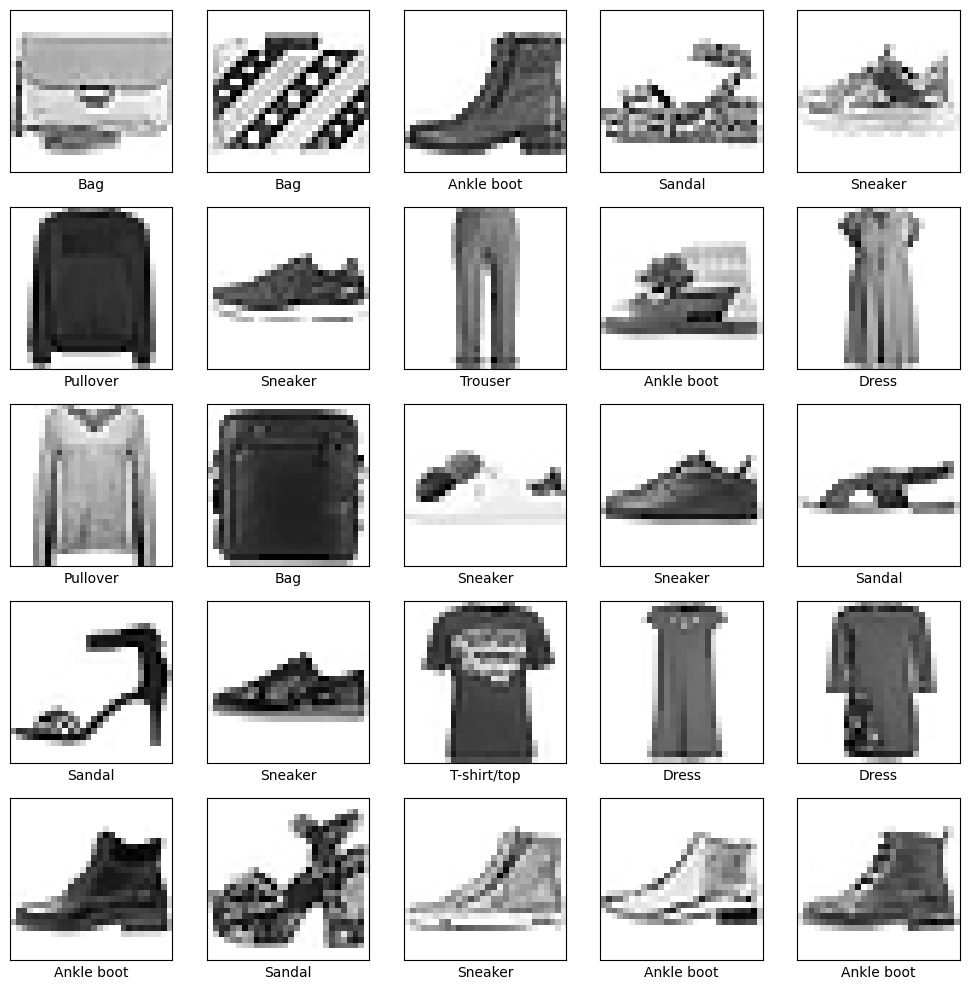

In [25]:
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)  # 5 filas, 5 columnas
    plt.xticks([])  # Eliminar ejes X
    plt.yticks([])  # Eliminar ejes Y
    plt.imshow(train_images[i], cmap=plt.cm.binary)  # Mostrar en escala de grises
    plt.xlabel(class_names[train_labels[i]])  # Etiqueta = nombre de la clase

plt.tight_layout()  # Ajustar espaciado
plt.show()

## Construir el Modelo

Construir la red neuronal requiere configurar las capas del modelo y luego compilar el modelo.

### Configurar las Capas
Construye todas las capas del modelo.

In [26]:
capas = [
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(units = 300, activation='relu'),
    keras.layers.Dense(units = 100, activation='relu'),
    keras.layers.Dense(units = 10, activation='softmax')
]

model = keras.models.Sequential(capas)

c:\Users\amaci\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


### Compila el modelo

Antes de que el modelo este listo para entrenar , se necesitan algunas configuraciones más. Estas son agregadas durante el paso de compilacion del modelo:

* *Loss function* —Esto mide que tan exacto es el modelo durante el entrenamiento. Quiere minimizar esta función para dirigir el modelo en la dirección adecuada.
* *Optimizer* — Esto es cómo el modelo aprende basado en el set de datos que ve y la función de pérdida.
* *Metrics* — Se usan para monitorear los pasos de entrenamiento y de pruebas.


Como es un problema de clasificación multiclase, tendrás que usar `sparse_categorical_crossentropy` como función de coste. En cuanto a las métricas, usa simplemente `accuracy`.

In [27]:
model.compile(
    optimizer = "sgd",
    loss = "sparse_categorical_crossentropy",
    metrics = ["accuracy"]
)
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

## Entrenar el Modelo
Empieza entrenándolo con 10 epochs. Prueba con más

In [29]:
history = model.fit(
    train_images,
    train_labels,
    batch_size = 128,
    epochs = 10,
    validation_data = (val_images, val_labels) # validation_split = 0.1
)


Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5275 - loss: 1.5316 - val_accuracy: 0.7333 - val_loss: 59.3447
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7703 - loss: 0.7077 - val_accuracy: 0.7622 - val_loss: 63.6185
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8065 - loss: 0.5955 - val_accuracy: 0.7753 - val_loss: 68.5038
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8144 - loss: 0.5504 - val_accuracy: 0.7943 - val_loss: 66.3283
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8280 - loss: 0.5110 - val_accuracy: 0.7982 - val_loss: 70.3417
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8308 - loss: 0.4906 - val_accuracy: 0.8023 - val_loss: 70.3687
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8376 - loss: 0.4750 - val_accuracy: 0.8005 - val_loss: 73.7234
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8410 - loss: 0.4619 - val_accur

## Evaluar Accuracy
Prueba el rendimiento del modelo con los datos de test

In [30]:
results = model.evaluate(test_images, test_labels)
results

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8323 - loss: 0.4700


[0.47227632999420166, 0.8291000127792358]

## Hacer predicciones

Con el modelo entrenado puedes usarlo para hacer predicciones sobre imagenes.

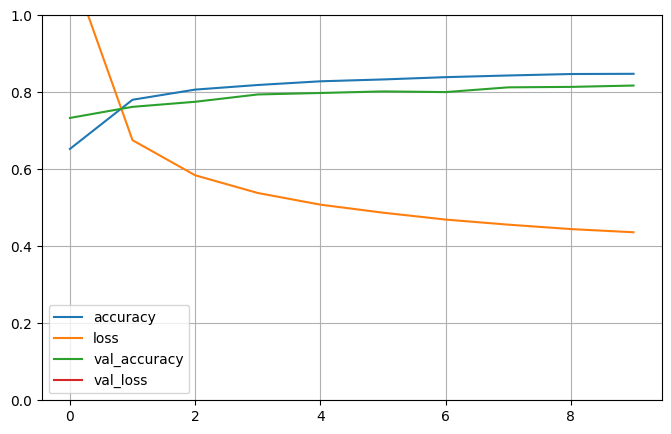

In [31]:
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1) # set the vertical range to [0-1]
plt.show()

C:\Users\amaci\AppData\Local\Temp\ipykernel_17372\3446505541.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  plt.imshow(test_images[0].reshape(28,28), cmap=plt.cm.get_cmap('Greys'));


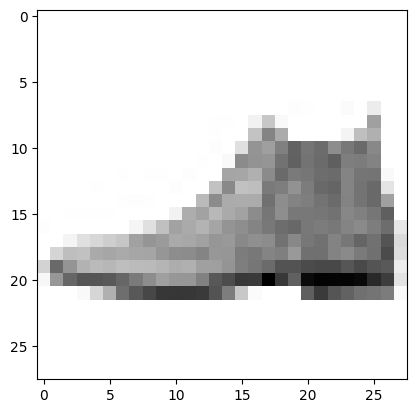

In [51]:
plt.imshow(test_images[0].reshape(28,28), cmap=plt.cm.get_cmap('Greys'));

In [61]:
predictions = model.predict(test_images[:10])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


In [62]:
predictions.argmax()

np.int64(21)

El modelo ha predicho la etiqueta para cada imagen en el set de datos de *test* (prueba). Miremos la primera prediccion:

*Una* prediccion es un array de 10 numeros. Estos representan el nivel de "confianza" del modelo sobre las imagenes de cada uno de los 10 articulos de moda/ropa. Puedes revisar cual tiene el nivel mas alto de confianza:

In [63]:
print(predictions.shape)
np.round(predictions,3)

(10, 10)


array([[0.   , 0.   , 0.   , 0.   , 0.   , 0.108, 0.   , 0.235, 0.004,
        0.653],
       [0.   , 0.   , 0.765, 0.   , 0.013, 0.   , 0.222, 0.   , 0.   ,
        0.   ],
       [0.   , 1.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
        0.   ],
       [0.   , 0.999, 0.   , 0.001, 0.   , 0.   , 0.   , 0.   , 0.   ,
        0.   ],
       [0.077, 0.001, 0.072, 0.015, 0.018, 0.   , 0.815, 0.   , 0.002,
        0.   ],
       [0.005, 0.987, 0.001, 0.001, 0.006, 0.   , 0.   , 0.   , 0.   ,
        0.   ],
       [0.032, 0.003, 0.039, 0.003, 0.688, 0.002, 0.222, 0.   , 0.01 ,
        0.   ],
       [0.001, 0.   , 0.026, 0.004, 0.101, 0.   , 0.866, 0.   , 0.002,
        0.   ],
       [0.018, 0.016, 0.017, 0.019, 0.007, 0.74 , 0.024, 0.115, 0.039,
        0.005],
       [0.   , 0.   , 0.   , 0.   , 0.   , 0.029, 0.   , 0.963, 0.003,
        0.004]], dtype=float32)

Entonces, el modelo tiene mayor confianza que esta imagen es un bota de tobillo "ankle boot" o `class_names[9]`. Examinando las etiquetas de *test* o de pruebas muestra que esta clasificación es correcta:

**Grafica** esto para poder ver todo el set de la prediccion de las 10 clases.

In [64]:
predicted_indices = np.argmax(predictions, axis = 1)
predicted_label = [class_names [i] for i in predicted_indices]

for i, label in enumerate (predicted_label):
    print(f'Imagen {i+1}: {label}')

Imagen 1: Ankle boot
Imagen 2: Pullover
Imagen 3: Trouser
Imagen 4: Trouser
Imagen 5: Shirt
Imagen 6: Trouser
Imagen 7: Coat
Imagen 8: Shirt
Imagen 9: Sandal
Imagen 10: Sneaker


Miremos la imagen [0], sus predicciones y el array de predicciones. Las etiquetas de predicción correctas estan en azul y las incorrectas están en rojo. El número entrega el porcentaje (sobre 100) para la etiqueta predicha.

Vamos a graficar multiples imagenes con sus predicciones. Notese que el modelo puede estar equivocado aun cuando tiene mucha confianza.

Evalúa tu modelo con una matriz de confusión e interprétala.

In [59]:
confusion_matrix(test_labels, model.predict(test_images).argmax(axis=1))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([[739,   3,  11,  54,   5,   1, 170,   0,  17,   0],
       [  6, 938,  10,  36,   4,   0,   5,   0,   1,   0],
       [ 10,   3, 655,  10, 117,   1, 195,   0,   9,   0],
       [ 25,  11,   8, 863,  23,   1,  64,   0,   5,   0],
       [  0,   2,  87,  43, 693,   1, 167,   0,   7,   0],
       [  0,   0,   0,   1,   0, 924,   0,  50,   3,  22],
       [106,   2,  90,  43,  57,   1, 674,   0,  27,   0],
       [  0,   0,   0,   0,   0,  34,   0, 927,   0,  39],
       [  0,   1,   7,   7,   1,   5,  27,   5, 947,   0],
       [  0,   0,   0,   0,   0,  16,   1,  50,   2, 931]])

Finalmente, usamos el modelo entrenado para hacer una prediccion sobre una única imagen.